In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  
import torch
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer


In [2]:
seqs = pd.read_csv('data/Table_EV4.tsv', sep='\t')


In [3]:
seqs = seqs[['EnsemblGeneID','ProteinSequence']]
seqs_subset = seqs[:100]

tokenizer = AutoTokenizer.from_pretrained("esm2_t12_35M_UR50D")

input = tokenizer(list(seqs_subset['ProteinSequence']),return_tensors="pt",padding=True, truncation=True, max_length=1000)


In [5]:
model = AutoModelForSequenceClassification.from_pretrained("esm2_t12_35M_UR50D",num_labels=100)

Some weights of EsmForSequenceClassification were not initialized from the model checkpoint at esm2_t12_35M_UR50D and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
input['input_ids']

torch.Size([11575, 5000])

In [37]:
batch_size = 10 

results = []

with torch.no_grad():
    for i in range(0, len(input["input_ids"]), batch_size):
        batch_input = {k: v[i:i+batch_size] for k, v in input.items()}
        output = model(**batch_input)
        results.append(output.logits)

results = torch.cat(results, dim=0)


In [38]:
results.shape

torch.Size([100, 100])

EnsemblGeneID                                        ENSG00000155657
ProteinSequence    MTTQAPTFTQPLQSVVVLEGSTATFEAHISGFPVPEVSWFRDGQVI...
Name: 10714, dtype: object


(0.0, 100.0)

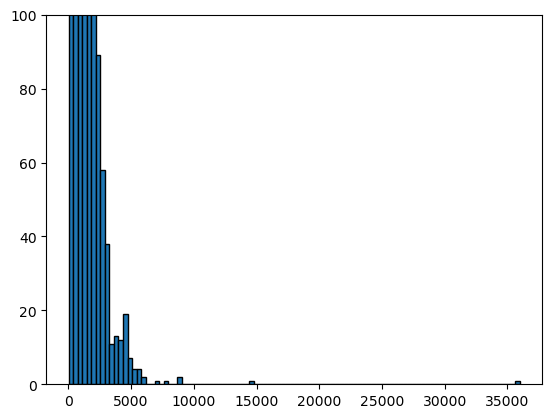

In [ ]:
genelengths = [len(seqs['ProteinSequence'][i]) for i in range(len(seqs['ProteinSequence']))]

plt.hist(genelengths, bins=100, edgecolor='black')
plt.ylim(0, 100)

Some weights of EsmForSequenceClassification were not initialized from the model checkpoint at . and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
